In [1]:
import numpy as np
import pandas as pd

In [2]:
with open('HomeDatasetTehran_R4_1402_11.txt','r', encoding='utf-8') as f:
    lines = f.readlines()
line_item = []
abnormal = [ 1,  3,  30,  33, 34]
c = 0
for l in lines:
    new_line = l.split('\t')
    c_item = len(new_line)
    if c_item in abnormal:
        c += 1
        continue
    new_line = new_line[:27]
    line_item.append('\t'.join(new_line))
with open('HomeDatasetTehranCleaned.txt','w', encoding='utf-8') as f:
    for line in line_item:
        f.write(line + '\n')

In [4]:
line_item[1]

'آپارتمان\t1402/11/09\tتهران پارس خ 184\t4\t5\t2\t12,500,000,000 تومان\tنوساز\tتخلیه\tسنگ\tشخصي\t0\t1\t0\t0\t2\t107\t2\t1\tMDF\tايراني فرنگي\tسراميک\t1\t1\t1\t1\tکولر_آسانسور_پکیج_گاز'

In [3]:
df = pd.read_csv('HomeDatasetTehranCleaned.txt', sep='\t')
df.head(2)

,h_type,date,adress,loc,num_floor,unit_per_floor,price,age,statuse,view,...,num_sleep,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment
0,آپارتمان,1402/11/09,تهران پارس خ 184,4,5,2,"12,500,000,000 تومان",نوساز,تخلیه,سنگ,...,2,1,MDF,ايراني فرنگي,سراميک,1,1,1,1,کولر_آسانسور_پکیج_گاز
1,آپارتمان,1402/11/18,تهرانپارس خ 184غربی,4,6,2,"28,215,000,000 تومان",نوساز,تخلیه,سنگ,...,3,2,MDF,ايراني فرنگي,سنگ,1,1,1,1,کولر_آسانسور_پکیج_گاز


In [701]:
df.date.value_counts()

date
1402/11/23    97
1402/11/14    92
1402/11/09    90
1402/11/10    86
1402/11/15    85
1402/11/16    81
1402/11/17    80
1402/11/18    76
1402/11/25    72
1402/11/11    66
1402/11/24    62
1402/11/12    48
1402/11/26    14
1402/11/08    11
Name: count, dtype: int64

In [702]:
df.columns

Index(['h_type', 'date', 'adress', 'loc', 'num_floor', 'unit_per_floor',
       'price', 'age', 'statuse', 'view', 'doc_status', 'north', 'sought',
       'west', 'east', 'floor', 'area', 'num_sleep', 'tel', 'kitch', 'service',
       'floor_covering', 'open', 'parking', 'warehouse', 'balcony',
       'equipment'],
      dtype='object')

In [4]:
df = df.drop(['h_type','date','loc'], axis = 'columns')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   adress          960 non-null    object
 1   num_floor       960 non-null    int64 
 2   unit_per_floor  960 non-null    int64 
 3   price           960 non-null    object
 4   age             960 non-null    object
 5   statuse         960 non-null    object
 6   view            960 non-null    object
 7   doc_status      960 non-null    object
 8   north           960 non-null    int64 
 9   sought          960 non-null    int64 
 10  west            960 non-null    int64 
 11  east            960 non-null    int64 
 12  floor           960 non-null    object
 13  area            960 non-null    int64 
 14  num_sleep       960 non-null    int64 
 15  tel             960 non-null    int64 
 16  kitch           960 non-null    object
 17  service         960 non-null    object
 18  floor_cove

In [6]:
df.shape

(960, 24)

In [7]:
df.columns

Index(['adress', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment'],
      dtype='object')

In [10]:
df['adress'].nunique() 

643

In [11]:
address = df['adress'].value_counts() 
address[address == 5]

adress
هروی خ افتخاریان                 5
جشنواره خ امین                   5
اتوبان بابایی شهرك شهید بهشتی    5
تهرانپارس فلكه اول               5
هروی خ ضابطی                     5
قنات كوثر بلوار مطهری            5
تهرانپارس بلوار پروین خ 216      5
تهرانپارس استخر                  5
Name: count, dtype: int64

In [8]:
def convert_price(price_str):
    return int(price_str.replace(',', '').replace(' تومان', ''))

df['price'] = df['price'].apply(convert_price)

In [13]:
df['price'] = df['price'] / df['area']
df['price']

0      1.168224e+08
1      1.350000e+08
2      1.800000e+08
3      3.937500e+07
4      6.206897e+07
           ...     
955    1.030303e+08
956    1.400000e+08
957    9.793814e+07
958    5.428571e+07
959    1.100000e+08
Name: price, Length: 960, dtype: float64

In [9]:
main_addres = ['استخر','پروین','خواجه عبدالله','شمیران نو','بنی هاشم','نیروی دریایی','میدان شاهد',
'فرجام','مجیدیه','تهران پارس','جشنواره','هروی','حكیمیه','شمس اباد','اتوبان بابایی','شمس آباد',
'دلاوران','دماوند','سراج','رسالت','لویزان',
'تهرانپارس','شهیدعراقی','شهید عراقی', 'شمس آّباد','هنگام','تهارنپارس',
'قنات كوثر','نیروی دریائی','ایت','خواجه عبداله','شریعتی']

def replace_address(s):
    for each_address in main_addres:
        if each_address in s:
            s = each_address
    return s

df['adress'] = df['adress'].apply(replace_address)
df['adress'].unique()

array(['تهران پارس', 'تهرانپارس', 'شهیدعراقی', 'جشنواره', 'فرجام',
       'شمس آباد', 'هروی', 'حكیمیه', 'شمیران نو', 'خواجه عبدالله',
       'رسالت', 'اتوبان بابایی', 'ایت', 'شهید عراقی', 'قنات كوثر',
       'شمس اباد', 'لویزان', 'استخر', 'سراج', 'نیروی دریائی', 'پروین',
       'مجیدیه', 'بنی هاشم', 'هنگام', 'بزرگراه بابائی شهرك شهپریان',
       'میدان شاهد', 'دلاوران', 'شریعتی', 'تهرانبارس خ محمدخانی',
       'خواجه عبداله', 'نیروی دریایی', 'دماوند',
       'بزرگراه بابایی شهرك كوثر', 'بزرگراه بابائی شهرك بهشتی',
       'شهرك راه آهن بلواركوهك'], dtype=object)

In [11]:
correct_address = {address:address for address in df['adress']}
correct_address

{'تهران پارس': 'تهران پارس',
 'تهرانپارس': 'تهرانپارس',
 'شهیدعراقی': 'شهیدعراقی',
 'جشنواره': 'جشنواره',
 'فرجام': 'فرجام',
 'شمس آباد': 'شمس آباد',
 'هروی': 'هروی',
 'حكیمیه': 'حكیمیه',
 'شمیران نو': 'شمیران نو',
 'خواجه عبدالله': 'خواجه عبدالله',
 'رسالت': 'رسالت',
 'اتوبان بابایی': 'اتوبان بابایی',
 'ایت': 'ایت',
 'شهید عراقی': 'شهید عراقی',
 'قنات كوثر': 'قنات كوثر',
 'شمس اباد': 'شمس اباد',
 'لویزان': 'لویزان',
 'استخر': 'استخر',
 'سراج': 'سراج',
 'نیروی دریائی': 'نیروی دریائی',
 'پروین': 'پروین',
 'مجیدیه': 'مجیدیه',
 'بنی هاشم': 'بنی هاشم',
 'هنگام': 'هنگام',
 'بزرگراه بابائی شهرك شهپریان': 'بزرگراه بابائی شهرك شهپریان',
 'میدان شاهد': 'میدان شاهد',
 'دلاوران': 'دلاوران',
 'شریعتی': 'شریعتی',
 'تهرانبارس خ محمدخانی': 'تهرانبارس خ محمدخانی',
 'خواجه عبداله': 'خواجه عبداله',
 'نیروی دریایی': 'نیروی دریایی',
 'دماوند': 'دماوند',
 'بزرگراه بابایی شهرك كوثر': 'بزرگراه بابایی شهرك كوثر',
 'بزرگراه بابائی شهرك بهشتی': 'بزرگراه بابائی شهرك بهشتی',
 'شهرك راه آهن بلواركوهك': 'شهرك راه آ

In [12]:
correct_address['تهارنپارس'] = 'تهرانپارس'
correct_address['شمس آباد'] = 'شمس آّباد'
correct_address['شمس آّباد'] = 'شمس آّباد'
correct_address['شمس اباد'] = 'شمس آّباد'
correct_address['خواجه عبداله'] = 'خواجه عبدالله'
correct_address['نیروی دریائی'] = 'نیروی دریایی'
correct_address['تهران پارس'] = 'تهرانپارس'
correct_address['بزرگراه بابایی شهرك كوثر'] = 'اتوبان بابایی'
correct_address['تهرانبارس خ محمدخانی'] = 'تهرانپارس'

df['adress'] = df['adress'].map(correct_address)
df['adress'].unique()

array(['تهرانپارس', 'شهیدعراقی', 'جشنواره', 'فرجام', 'شمس آّباد', 'هروی',
       'حكیمیه', 'شمیران نو', 'خواجه عبدالله', 'رسالت', 'اتوبان بابایی',
       'ایت', 'شهید عراقی', 'قنات كوثر', 'لویزان', 'استخر', 'سراج',
       'نیروی دریایی', 'پروین', 'مجیدیه', 'بنی هاشم', 'هنگام',
       'بزرگراه بابائی شهرك شهپریان', 'میدان شاهد', 'دلاوران', 'شریعتی',
       'دماوند', 'بزرگراه بابائی شهرك بهشتی', 'شهرك راه آهن بلواركوهك'],
      dtype=object)

In [13]:
df.head(2)

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,num_sleep,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment
0,تهرانپارس,5,2,12500000000,نوساز,تخلیه,سنگ,شخصي,0,1,...,2,1,MDF,ايراني فرنگي,سراميک,1,1,1,1,کولر_آسانسور_پکیج_گاز
1,تهرانپارس,6,2,28215000000,نوساز,تخلیه,سنگ,شخصي,0,1,...,3,2,MDF,ايراني فرنگي,سنگ,1,1,1,1,کولر_آسانسور_پکیج_گاز


In [14]:
df.floor.unique()
replace_floor = {floor:floor for floor in df.floor}
replace_floor

{'2': '2',
 '1': '1',
 'همكف': 'همكف',
 '4': '4',
 '3': '3',
 'مختلف': 'مختلف',
 '6': '6',
 '5': '5',
 '9': '9',
 'زیرهمكف': 'زیرهمكف',
 '7': '7',
 '8': '8',
 '10': '10',
 '11': '11',
 '13': '13',
 '17': '17',
 '15': '15',
 'پ': 'پ',
 '12': '12'}

In [15]:
replace_floor = {'5': '5',
 '2': '2',
 '4': '4',
 'همكف': '0',
 '3': '3',
 '1': '1',
 'مختلف': '2',
 '7': '7',
 'زیرهمكف': '-1',
 '11': '11',
 '6': '6',
 '13': '13',
 '8': '8',
 '1و2و4و5': '15',
 '1و2': '12',
 '9': '9',
 '14': '14',
 '1و3': '13',
 '10': '10',
 '3و4': '34',
 '12': '12',
 '18': '18'}

df['floor'] = df['floor'].map(replace_floor)
df['floor'] = df['floor'].astype(float)
df.floor.unique()

array([ 2.,  1.,  0.,  4.,  3.,  6.,  5.,  9., -1.,  7.,  8., 10., 11.,
       13., nan, 12.])

In [21]:
df.age=df.age.str.replace('نوساز','0')

In [22]:
df.age = df.age.astype(int)

In [718]:
df.columns

Index(['adress', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment'],
      dtype='object')

In [23]:
df.equipment.dtype

dtype('O')

In [24]:
df.equipment

0          کولر_آسانسور_پکیج_گاز
1          کولر_آسانسور_پکیج_گاز
2               کولر_آسانسور_گاز
3                       کولر_گاز
4                 شوفاژ_کولر_گاز
                 ...            
955    شوفاژ_کولر_سونا_جکوزی_گاز
956             کولر_آسانسور_گاز
957        کولر_آسانسور_پکیج_گاز
958                کولر_پکیج_گاز
959        کولر_آسانسور_پکیج_گاز
Name: equipment, Length: 960, dtype: object

In [16]:
equipment_name = []
for res in df.equipment:
    if res == np.nan or type(res) == float:
        res = np.nan
    else:
        split_res = res.split('_')
        for item in split_res:
            equipment_name.append(item)
equipment_items = set(equipment_name)
print(equipment_items)

{'چیلر', 'گاز', 'مستخدم', 'جکوزی', 'فن کوئر', 'پکیج', 'حیاط خلوت', 'کولر', 'زیر زمین', 'استخر', 'حیاط', 'شوفاژ', 'سونا', 'آسانسور', 'پاسیو'}


In [19]:
for item in equipment_items:
    df[item] = 0

In [27]:
df.shape

(960, 39)

In [18]:
df.iloc[0:5, -16:]

,north,sought,west,east,floor,area,num_sleep,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment
0,0,1,0,0,2.0,107,2,1,MDF,ايراني فرنگي,سراميک,1,1,1,1,کولر_آسانسور_پکیج_گاز
1,0,1,0,0,1.0,209,3,2,MDF,ايراني فرنگي,سنگ,1,1,1,1,کولر_آسانسور_پکیج_گاز
2,1,0,0,1,2.0,107,2,1,هایگلاس,ايراني فرنگي,سراميک,1,1,1,1,کولر_آسانسور_گاز
3,0,1,0,0,0.0,48,1,1,MDF,ايرانی,سراميک,1,0,1,0,کولر_گاز
4,0,1,0,0,4.0,58,1,1,MDF,ايرانی,سراميک,1,1,1,0,شوفاژ_کولر_گاز


In [20]:
df.insert(loc=35, column='items', value=np.nan)
def equip_map(res):
    if res == np.nan or type(res)==float:
        return(np.nan)
    else:
        split_res = res.split('_')
        # print(split_res)
        return(split_res)
df['items'] = df['equipment'].map(equip_map)

In [21]:
equipment_lst = ['items', 'گاز','چیلر', 'استخر', 'زیر زمین', 'آسانسور', 'شوفاژ', 'فن کوئر', 'جکوزی',
                  'کولر', 'پکیج', 'حیاط', 'حیاط خلوت', 'سونا', 'مستخدم', 'پاسیو']

In [22]:
df.loc[0:5, equipment_lst]

,items,گاز,چیلر,استخر,زیر زمین,آسانسور,شوفاژ,فن کوئر,جکوزی,کولر,پکیج,حیاط,حیاط خلوت,سونا,مستخدم,پاسیو
0,"[کولر, آسانسور, پکیج, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,"[کولر, آسانسور, پکیج, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,"[کولر, آسانسور, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,"[کولر, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,"[شوفاژ, کولر, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,"[شوفاژ, کولر, گاز]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
df['items'][0]

['کولر', 'آسانسور', 'پکیج', 'گاز']

In [ ]:
for i in range(len(df['items'].values)):
    equipment_index = df['items'][i]
    if type(equipment_index) == float or equipment_index == np.nan:
        equipment_index = np.nan
    else:
        for j in  equipment_index:
            df.loc[i, j] = 1

In [26]:
df.loc[0:5, equipment_lst]

,items,گاز,چیلر,استخر,زیر زمین,آسانسور,شوفاژ,فن کوئر,جکوزی,کولر,پکیج,حیاط,حیاط خلوت,سونا,مستخدم,پاسیو
0,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0,1,0,0,0,1,1,0,0,0,0,0
1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0,1,0,0,0,1,1,0,0,0,0,0
2,"[کولر, آسانسور, گاز]",1,0,0,0,1,0,0,0,1,0,0,0,0,0,0
3,"[کولر, گاز]",1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,"[شوفاژ, کولر, گاز]",1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
5,"[شوفاژ, کولر, گاز]",1,0,0,0,0,1,0,0,1,0,0,0,0,0,0


In [27]:
df[df.equipment.isna()]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,حیاط خلوت,کولر,زیر زمین,استخر,حیاط,items,شوفاژ,سونا,آسانسور,پاسیو
437,پروین,4,2,3400000000,15,مسکونی,سنگ,شخصي,1,0,...,0,0,0,0,0,NaN,0,0,0,0
920,قنات كوثر,4,1,5700000000,22,مسکونی,سنگ,شخصي,0,1,...,0,0,0,0,0,NaN,0,0,0,0


In [28]:
english_words = {'گاز': 'Gas', 'زیر زمین':'Basement',
                  'چیلر':'Chiller', 'حیاط':'Yard', 'جکوزی':'Jacuzzi',
                    'فن کوئر':'Fan coil', 'پکیج':'Package', 'سونا':'Sauna', 'مستخدم':'User',
                      'کولر':'Cooler', 'استخر':'Pool', 'شوفاژ':'Fireplace', 'پاسیو':'Patio',
                        'حیاط خلوت':'Secluded yard', 'آسانسور':'Elevator'}
# equipment_lst = ['items', 'گاز','چیلر', 'استخر', 'زیر زمین', 'آسانسور', 'شوفاژ', 'فن کوئر', 'جکوزی',
#                   'کولر', 'پکیج', 'حیاط', 'حیاط خلوت', 'سونا', 'مستخدم', 'پاسیو']

df = df.rename(columns=english_words)
df

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Secluded yard,Cooler,Basement,Pool,Yard,items,Fireplace,Sauna,Elevator,Patio
0,تهرانپارس,5,2,12500000000,نوساز,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,0,"[کولر, آسانسور, پکیج, گاز]",0,0,1,0
1,تهرانپارس,6,2,28215000000,نوساز,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,0,"[کولر, آسانسور, پکیج, گاز]",0,0,1,0
2,شهیدعراقی,4,2,19260000000,نوساز,تخلیه,سنگ,شخصي,1,0,...,0,1,0,0,0,"[کولر, آسانسور, گاز]",0,0,1,0
3,جشنواره,4,1,1890000000,12,مسکونی,سنگ,قولنامه اي,0,1,...,0,1,0,0,0,"[کولر, گاز]",0,0,0,0
4,تهرانپارس,4,2,3600000000,20,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,بنی هاشم,4,1,6800000000,17,اجاره,سنگ,شخصي,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, سونا, جکوزی, گاز]",1,1,0,0
956,تهرانپارس,5,1,25200000000,نوساز,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,0,"[کولر, آسانسور, گاز]",0,0,1,0
957,تهرانپارس,5,2,9500000000,10,مسکونی,سنگ,شخصي,1,0,...,0,1,0,0,0,"[کولر, آسانسور, پکیج, گاز]",0,0,1,0
958,پروین,4,2,3800000000,12,مسکونی,سنگ,شخصي,0,1,...,0,1,0,0,0,"[کولر, پکیج, گاز]",0,0,0,0


In [733]:
df

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
0,تهرانپارس,5,2,1.168224e+08,0,تخلیه,سنگ,شخصي,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
1,تهرانپارس,6,2,1.350000e+08,0,تخلیه,سنگ,شخصي,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
2,شهیدعراقی,4,2,1.800000e+08,0,تخلیه,سنگ,شخصي,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
3,جشنواره,4,1,3.937500e+07,12,مسکونی,سنگ,قولنامه اي,0,1,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
4,تهرانپارس,4,2,6.206897e+07,20,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,بنی هاشم,4,1,1.030303e+08,17,اجاره,سنگ,شخصي,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, سونا, جکوزی, گاز]",1,0,0,0
956,تهرانپارس,5,1,1.400000e+08,0,تخلیه,سنگ,شخصي,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
957,تهرانپارس,5,2,9.793814e+07,10,مسکونی,سنگ,شخصي,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
958,پروین,4,2,5.428571e+07,12,مسکونی,سنگ,شخصي,0,1,...,1,1,0,0,0,"[کولر, پکیج, گاز]",1,0,0,0


In [29]:
print('Number of missing values:')
for col in df.columns:
    n_MV = sum(df[col].isna())
    print(f'{col}:{n_MV}')

Number of missing values:
adress:0
num_floor:0
unit_per_floor:0
price:0
age:0
statuse:0
view:0
doc_status:0
north:0
sought:0
west:0
east:0
floor:3
area:0
num_sleep:0
tel:0
kitch:0
service:0
floor_covering:0
open:0
parking:0
warehouse:0
balcony:0
equipment:2
Chiller:0
Gas:0
User:0
Jacuzzi:0
Fan coil:0
Package:0
Secluded yard:0
Cooler:0
Basement:0
Pool:0
Yard:0
items:2
Fireplace:0
Sauna:0
Elevator:0
Patio:0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    object 
 6   view            960 non-null    object 
 7   doc_status      960 non-null    object 
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           957 non-null    float64
 13  area            960 non-null    int64  
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           960 non-null    object 
 17  service         960 non-null    obj

#### Status part

In [736]:
df[df["statuse"].isna()]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil


In [737]:
df["statuse"]

0       تخلیه
1       تخلیه
2       تخلیه
3      مسکونی
4       تخلیه
        ...  
955     اجاره
956     تخلیه
957    مسکونی
958    مسکونی
959     تخلیه
Name: statuse, Length: 960, dtype: object

In [30]:
df.drop(['equipment','items'],axis='columns',inplace=True)

In [31]:
target_map = {
    'تخلیه': 3,
    'مسکونی': 1,
    'اجاره': 1
}
df['statuse'] = df['statuse'].map(target_map)

In [41]:
df["statuse"]

0      3
1      3
2      3
3      1
4      3
      ..
955    1
956    3
957    1
958    1
959    3
Name: statuse, Length: 960, dtype: int64

In [32]:
df["statuse"] = df["statuse"].astype(float)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    float64
 6   view            960 non-null    object 
 7   doc_status      960 non-null    object 
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           957 non-null    float64
 13  area            960 non-null    int64  
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           960 non-null    object 
 17  service         960 non-null    obj

#### View part

In [33]:
df[df["view"] == "کنيتکس"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Secluded yard,Cooler,Basement,Pool,Yard,Fireplace,Sauna,Elevator,Patio
700,شمس آّباد,4,2,5050000000,25,1.0,کنيتکس,شخصي,1,0,...,0,0,1,0,0,0,0,0,0,0


In [34]:
target_map = {
    'آجر': 1,
    'سيمان': -1,
    'سنگ': 7,
    "گرانيت": 9,
    "آجر سه سانت": 5,
    "ترکیبی": 8,
    "سنگ و رومي": 10,
    "تراورتن": 9,
    "رومي": 10,
    "رومالین": -1,
    "کنيتکس": -1
}
df['view'] = df['view'].map(target_map)

In [744]:
df.head()

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
0,تهرانپارس,5,2,1.168224e+08,0,1.0,3,شخصي,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,شخصي,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
2,شهیدعراقی,4,2,1.800000e+08,0,1.0,3,شخصي,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
3,جشنواره,4,1,3.937500e+07,12,2.0,3,قولنامه اي,0,1,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
4,تهرانپارس,4,2,6.206897e+07,20,1.0,3,شخصي,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0


In [745]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    float64
 6   view            960 non-null    int64  
 7   doc_status      960 non-null    object 
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           957 non-null    float64
 13  area            960 non-null    int64  
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           960 non-null    object 
 17  service         960 non-null    obj

#### Doc_Status part

In [746]:
df[df["doc_status"] == "دردست اقدام"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
149,پروین,6,4,8.000000e+07,0,1.0,6,دردست اقدام,0,1,...,1,0,0,0,1,"[آسانسور, پکیج]",0,0,0,0
162,تهرانپارس,5,1,1.400000e+08,0,1.0,6,دردست اقدام,0,1,...,0,0,0,0,1,"[آسانسور, چیلر]",0,1,0,0
213,هروی,10,7,1.100000e+08,0,1.0,3,دردست اقدام,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
287,تهرانپارس,6,2,1.150000e+08,1,3.0,3,دردست اقدام,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
436,تهرانپارس,5,1,1.700000e+08,6,1.0,3,دردست اقدام,0,1,...,0,1,0,0,1,"[آسانسور, چیلر, گاز]",0,1,0,0
443,هروی,12,11,1.200000e+08,0,1.0,3,دردست اقدام,0,0,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
444,رسالت,5,4,7.000000e+07,2,1.0,3,دردست اقدام,1,0,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0
460,هروی,11,12,1.300000e+08,0,1.0,3,دردست اقدام,1,0,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
739,تهرانپارس,10,7,1.206897e+08,0,1.0,3,دردست اقدام,1,1,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
779,رسالت,5,2,6.200000e+07,2,3.0,3,دردست اقدام,1,0,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0


In [35]:
target_map = {
    "دردست اقدام": 3,
    'شخصي': 6,
    'قولنامه اي': 0,
    'تعاوني': 4,
    "اوقافي": 2,
    "وکالتي": 0
}
df['doc_status'] = df['doc_status'].map(target_map)

In [748]:
df

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
0,تهرانپارس,5,2,1.168224e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
2,شهیدعراقی,4,2,1.800000e+08,0,1.0,3,1.0,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
3,جشنواره,4,1,3.937500e+07,12,2.0,3,2.0,0,1,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
4,تهرانپارس,4,2,6.206897e+07,20,1.0,3,1.0,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,بنی هاشم,4,1,1.030303e+08,17,3.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, سونا, جکوزی, گاز]",1,0,0,0
956,تهرانپارس,5,1,1.400000e+08,0,1.0,3,1.0,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
957,تهرانپارس,5,2,9.793814e+07,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
958,پروین,4,2,5.428571e+07,12,2.0,3,1.0,0,1,...,1,1,0,0,0,"[کولر, پکیج, گاز]",1,0,0,0


In [749]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    float64
 6   view            960 non-null    int64  
 7   doc_status      959 non-null    float64
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           957 non-null    float64
 13  area            960 non-null    int64  
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           960 non-null    object 
 17  service         960 non-null    obj

#### Kitchen part

In [36]:
copyDf = df.copy()
copyDf

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Secluded yard,Cooler,Basement,Pool,Yard,Fireplace,Sauna,Elevator,Patio
0,تهرانپارس,5,2,12500000000,نوساز,3.0,7,6.0,0,1,...,1,0,1,0,0,0,0,0,1,0
1,تهرانپارس,6,2,28215000000,نوساز,3.0,7,6.0,0,1,...,1,0,1,0,0,0,0,0,1,0
2,شهیدعراقی,4,2,19260000000,نوساز,3.0,7,6.0,1,0,...,0,0,1,0,0,0,0,0,1,0
3,جشنواره,4,1,1890000000,12,1.0,7,0.0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,تهرانپارس,4,2,3600000000,20,3.0,7,6.0,0,1,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,بنی هاشم,4,1,6800000000,17,1.0,7,6.0,1,0,...,0,0,1,0,0,0,1,1,0,0
956,تهرانپارس,5,1,25200000000,نوساز,3.0,7,6.0,0,1,...,0,0,1,0,0,0,0,0,1,0
957,تهرانپارس,5,2,9500000000,10,1.0,7,6.0,1,0,...,1,0,1,0,0,0,0,0,1,0
958,پروین,4,2,3800000000,12,1.0,7,6.0,0,1,...,1,0,1,0,0,0,0,0,0,0


In [751]:
copyDf["kitch"]

0          MDF
1          MDF
2      هایگلاس
3          MDF
4          MDF
        ...   
955        MDF
956       چوبي
957        MDF
958        MDF
959        MDF
Name: kitch, Length: 960, dtype: object

In [752]:
copyDf[copyDf["kitch"] == "چوبي فلزي"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
685,تهرانپارس,4,2,7.397260e+07,20,2.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0


In [37]:
target_map = {
    "ندارد": 0,
    'چوبي': 4,
    "فلزي": 2,
    "چوبي فلزي": 3,
    "MDF": 5,
    'هایگلاس': 6,
    'نيمه مبله': 1,
    "دلخواه": 0,
    "نا مشخص": 0
}
copyDf['kitch'] = copyDf['kitch'].map(target_map)

In [38]:
copyDf.iloc[570:590, 14:19]

,num_sleep,tel,kitch,service,floor_covering
570,2,1,5,ايراني فرنگي,پارکت
571,1,1,5,ايرانی,سراميک
572,2,1,5,ايراني فرنگي,سنگ
573,2,1,5,ايراني فرنگي,سراميک
574,3,1,5,ايراني فرنگي,سراميک
575,2,1,5,ايرانی,سراميک
576,2,1,4,ايراني فرنگي,پارکت
577,2,1,5,ايراني فرنگي,سراميک
578,1,1,5,ايرانی,سراميک
579,1,1,5,ايراني فرنگي,سنگ


#### Service part

In [755]:
copyDf["service"]

0      ايراني فرنگي
1      ايراني فرنگي
2      ايراني فرنگي
3            ايرانی
4            ايرانی
           ...     
955    ايراني فرنگي
956    ايراني فرنگي
957    ايراني فرنگي
958    ايراني فرنگي
959    ايراني فرنگي
Name: service, Length: 960, dtype: object

In [756]:
copyDf[copyDf["service"] == "فرنگی"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
116,شهید عراقی,3,3,1.136364e+08,30,3.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
171,تهرانپارس,5,4,7.686275e+07,19,2.0,3,1.0,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
260,شمیران نو,3,2,3.636364e+07,12,2.0,3,2.0,1,0,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
373,تهرانپارس,3,2,7.464286e+07,15,2.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
475,جشنواره,5,4,7.500000e+07,13,2.0,3,1.0,1,0,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
517,استخر,4,1,7.727273e+07,7,2.0,3,1.0,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
556,سراج,4,3,6.083333e+07,25,2.0,3,1.0,1,0,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
636,سراج,4,2,7.500000e+07,22,3.0,3,1.0,1,0,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
765,تهرانپارس,5,4,8.076923e+07,18,2.0,3,1.0,1,0,...,0,1,1,0,1,"[شوفاژ, کولر, آسانسور, استخر, سونا, جکوزی, گاز]",1,0,0,0
803,تهرانپارس,4,2,5.652174e+07,25,2.0,3,1.0,1,0,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0


In [39]:
target_map = {
    "ايرانی": 1,
    "فرنگی": 2,
    'ايراني فرنگي': 3,
}
copyDf['service'] = copyDf['service'].map(target_map)

In [758]:
copyDf.iloc[571:580, 14:21]

,num_sleep,tel,kitch,service,floor_covering,open,parking
571,1,1,4.0,1,سراميک,1,0
572,2,1,4.0,3,سنگ,1,1
573,2,1,4.0,3,سراميک,1,1
574,3,1,4.0,3,سراميک,1,0
575,2,1,4.0,1,سراميک,1,1
576,2,1,1.0,3,پارکت,1,0
577,2,1,4.0,3,سراميک,1,1
578,1,1,4.0,1,سراميک,1,0
579,1,1,4.0,3,سنگ,1,0


#### Floor_Covering part

In [759]:
copyDf[copyDf["floor_covering"] == "سنگ"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
6,فرجام,5,4,1.025641e+08,2,1.0,3,1.0,0,1,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0
8,شمس آّباد,4,1,1.000000e+08,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0
10,تهرانپارس,4,2,8.362069e+07,22,1.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
15,فرجام,4,1,9.000000e+07,30,3.0,3,1.0,0,0,...,1,1,0,0,0,"[شوفاژ, کولر, پکیج, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,فرجام,5,2,9.890110e+07,15,1.0,3,1.0,1,0,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
948,تهرانپارس,5,3,1.091837e+08,6,2.0,3,1.0,0,1,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
956,تهرانپارس,5,1,1.400000e+08,0,1.0,3,1.0,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
957,تهرانپارس,5,2,9.793814e+07,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0


In [760]:
copyDf[copyDf["floor_covering"] == "سنگ"]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
6,فرجام,5,4,1.025641e+08,2,1.0,3,1.0,0,1,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0
8,شمس آّباد,4,1,1.000000e+08,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[شوفاژ, کولر, آسانسور, پکیج, گاز]",1,0,0,0
10,تهرانپارس,4,2,8.362069e+07,22,1.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
15,فرجام,4,1,9.000000e+07,30,3.0,3,1.0,0,0,...,1,1,0,0,0,"[شوفاژ, کولر, پکیج, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,فرجام,5,2,9.890110e+07,15,1.0,3,1.0,1,0,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
948,تهرانپارس,5,3,1.091837e+08,6,2.0,3,1.0,0,1,...,0,1,0,0,1,"[شوفاژ, کولر, آسانسور, گاز]",1,0,0,0
956,تهرانپارس,5,1,1.400000e+08,0,1.0,3,1.0,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
957,تهرانپارس,5,2,9.793814e+07,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0


In [40]:
target_map = {
    "سيمان": 1,
    "موزائيک": 2,
    "سراميک": 3,
    "موکت": 4,
    "سنگ": 5,
    'پارکت': 6,
    "پارکت سنگ": 7,
    "سنگ سراميک": 8,
    "لامنيت": 9,
    "کفپوش": 10,
    "نا مشخص": 0
}
copyDf['floor_covering'] = copyDf['floor_covering'].map(target_map)

In [762]:
copyDf.head()

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
0,تهرانپارس,5,2,1.168224e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
2,شهیدعراقی,4,2,1.800000e+08,0,1.0,3,1.0,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
3,جشنواره,4,1,3.937500e+07,12,2.0,3,2.0,0,1,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
4,تهرانپارس,4,2,6.206897e+07,20,1.0,3,1.0,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0


In [41]:
print('Number of missing values:')
for col in df.columns:
    n_MV = sum(df[col].isna())
    print(f'{col}:{n_MV}')

Number of missing values:
adress:0
num_floor:0
unit_per_floor:0
price:0
age:0
statuse:0
view:0
doc_status:1
north:0
sought:0
west:0
east:0
floor:3
area:0
num_sleep:0
tel:0
kitch:0
service:0
floor_covering:0
open:0
parking:0
warehouse:0
balcony:0
Chiller:0
Gas:0
User:0
Jacuzzi:0
Fan coil:0
Package:0
Secluded yard:0
Cooler:0
Basement:0
Pool:0
Yard:0
Fireplace:0
Sauna:0
Elevator:0
Patio:0


Checking missing values again

In [55]:
copyDf[copyDf["floor"].isna()].iloc[:,8:15]

,north,sought,west,east,floor,area,num_sleep
775,1,0,0,0,NaN,97,2
823,0,1,0,0,NaN,95,2
835,0,0,1,0,NaN,55,1


In [56]:
copyDf["floor"].mean()

2.819226750261233

In [766]:
copyDf[(copyDf["floor"].notna())].iloc[:, 14].mean()

1.8975966562173459

In [42]:
copyDf.loc[copyDf["floor"].isna(), "floor"] = copyDf[(copyDf["floor"].notna())].iloc[:, 14].mean()

In [59]:
copyDf[copyDf["floor"].isna()].iloc[:,8:15]

,north,sought,west,east,floor,area,num_sleep


In [60]:
copyDf[(copyDf.floor > 1) & (copyDf.floor < 2)].iloc[:, 8:14]

,north,sought,west,east,floor,area
775,1,0,0,0,1.897597,97
823,0,1,0,0,1.897597,95
835,0,0,1,0,1.897597,55


In [61]:
print('Number of missing values:')
for col in copyDf.columns:
    n_MV = sum(copyDf[col].isna())
    print(f'{col}:{n_MV}')

Number of missing values:
adress:0
num_floor:0
unit_per_floor:0
price:0
age:0
statuse:0
view:0
doc_status:1
north:0
sought:0
west:0
east:0
floor:0
area:0
num_sleep:0
tel:0
kitch:0
service:0
floor_covering:0
open:0
parking:0
warehouse:0
balcony:0
Fireplace:0
Chiller:0
Gas:0
Patio:0
Pool:0
Package:0
Elevator:0
Cooler:0
User:0
Fan coil:0
Basement:0
Jacuzzi:0
Secluded yard:0
Sauna:0
Yard:0


In [771]:
copyDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    float64
 6   view            960 non-null    int64  
 7   doc_status      959 non-null    float64
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           960 non-null    float64
 13  area            960 non-null    int64  
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           959 non-null    float64
 17  service         960 non-null    int

#### Outliers

In [62]:
copyDf.iloc[0:, 1:23]

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,area,num_sleep,tel,kitch,service,floor_covering,open,parking,warehouse,balcony
0,5,2,1.168224e+08,0,3.0,7,6.0,0,1,0,...,107,2,1,5,3,3,1,1,1,1
1,6,2,1.350000e+08,0,3.0,7,6.0,0,1,0,...,209,3,2,5,3,5,1,1,1,1
2,4,2,1.800000e+08,0,3.0,7,6.0,1,0,0,...,107,2,1,6,3,3,1,1,1,1
3,4,1,3.937500e+07,12,1.0,7,0.0,0,1,0,...,48,1,1,5,1,3,1,0,1,0
4,4,2,6.206897e+07,20,3.0,7,6.0,0,1,0,...,58,1,1,5,1,3,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,4,1,1.030303e+08,17,1.0,7,6.0,1,0,0,...,66,1,1,5,3,3,1,0,0,1
956,5,1,1.400000e+08,0,3.0,7,6.0,0,1,0,...,180,3,1,4,3,5,1,1,1,1
957,5,2,9.793814e+07,10,1.0,7,6.0,1,0,0,...,97,2,1,5,3,5,1,1,1,1
958,4,2,5.428571e+07,12,1.0,7,6.0,0,1,0,...,70,1,1,5,3,3,1,1,1,0


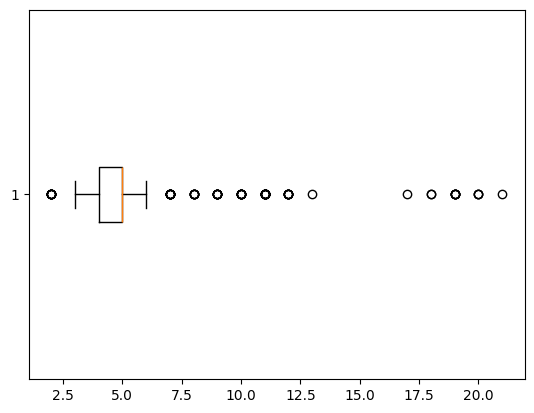

In [43]:
import matplotlib.pyplot as plt

fig = plt.boxplot(copyDf["num_floor"], vert=False)

In [64]:
fig['fliers'][0].get_data() 

(array([ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 11, 20,  7,  7, 10,  8, 11,
        19, 11,  7, 12, 11, 10,  7,  9,  7,  7,  8, 11,  9, 11, 19,  9,  7,
        10, 10,  9,  9,  9, 12, 12, 11, 11, 11, 10, 11, 11, 10, 11, 12,  7,
        13, 10, 11, 11, 20, 11, 11, 20, 17, 10,  9,  8, 19,  8, 10, 11, 12,
        19, 12, 19, 11, 12, 11,  7, 19,  7,  8,  7, 18,  8, 18,  9, 11, 11,
        21], dtype=int64),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1.]))

In [45]:
Q1 = copyDf["num_floor"].quantile(0.25)
Q3 = copyDf["num_floor"].quantile(0.75)
IQR = Q3-Q1

BM = (copyDf["num_floor"] > (Q3+1.5 *IQR)) | (copyDf["num_floor"] < (Q1-1.5 *IQR))
copyDf[BM]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Secluded yard,Cooler,Basement,Pool,Yard,Fireplace,Sauna,Elevator,Patio
24,هروی,11,9,23375000000,نوساز,3.0,7,6.0,1,0,...,0,0,1,0,0,0,1,0,1,0
30,اتوبان بابایی,20,10,8000000000,4,1.0,-1,4.0,0,1,...,0,0,1,0,0,0,1,0,1,0
35,شمس آّباد,7,4,6630000000,22,1.0,7,6.0,1,0,...,0,0,1,0,0,0,1,0,1,0
42,شمس آّباد,7,5,18200000000,نوساز,3.0,7,6.0,1,0,...,1,0,1,0,0,0,1,0,1,0
75,پروین,2,1,2500000000,1,3.0,7,0.0,0,1,...,1,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,تهرانپارس,9,2,6700000000,20,3.0,7,6.0,1,0,...,1,0,1,0,0,0,1,0,1,0
937,تهرانپارس,2,5,9800000000,30,1.0,7,6.0,0,1,...,0,0,1,0,0,0,1,0,0,0
941,هروی,11,10,15000000000,نوساز,3.0,7,6.0,1,1,...,1,0,1,0,0,0,1,0,1,0
947,هروی,11,9,15125000000,نوساز,3.0,7,6.0,1,0,...,0,0,1,0,0,0,1,0,1,0


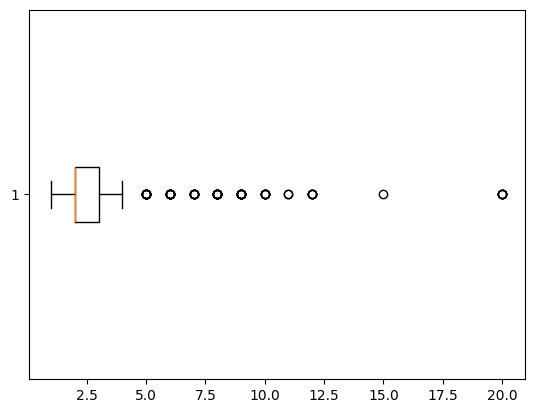

In [46]:
fig = plt.boxplot(copyDf["unit_per_floor"], vert=False)

In [67]:
fig['fliers'][0].get_data() 

(array([ 5,  9, 10,  5,  5,  8, 12,  6,  5,  6, 20,  9, 15, 10,  7,  5,  7,
         5,  6,  9,  9,  5, 20,  7,  5,  5,  8,  7,  6, 12,  6,  6,  8,  6,
         5, 11,  9, 12, 12,  7,  9, 12,  7,  9,  8,  8, 11, 10,  6,  9,  5,
         9, 20,  6,  8,  8,  5,  8,  8,  6, 20,  8,  6,  6,  7, 10,  8, 20,
         8,  8,  9,  8,  9, 10,  5, 10,  9], dtype=int64),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [47]:
Q1 = copyDf["unit_per_floor"].quantile(0.25)
Q3 = copyDf["unit_per_floor"].quantile(0.75)
IQR = Q3-Q1

BM = (copyDf["unit_per_floor"] > (Q3+1.5 *IQR)) | (copyDf["unit_per_floor"] < (Q1-1.5 *IQR))
copyDf[BM]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Secluded yard,Cooler,Basement,Pool,Yard,Fireplace,Sauna,Elevator,Patio
13,حكیمیه,4,5,5206000000,18,3.0,7,6.0,0,1,...,0,0,1,0,0,0,1,0,1,0
24,هروی,11,9,23375000000,نوساز,3.0,7,6.0,1,0,...,0,0,1,0,0,0,1,0,1,0
30,اتوبان بابایی,20,10,8000000000,4,1.0,-1,4.0,0,1,...,0,0,1,0,0,0,1,0,1,0
42,شمس آّباد,7,5,18200000000,نوساز,3.0,7,6.0,1,0,...,1,0,1,0,0,0,1,0,1,0
67,پروین,6,5,9500000000,1,3.0,7,6.0,0,1,...,0,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,هروی,7,9,19800000000,6,1.0,7,6.0,0,1,...,0,0,1,0,0,0,0,0,1,0
916,اتوبان بابایی,18,10,8774000000,نوساز,3.0,7,4.0,1,1,...,1,0,1,0,0,0,0,0,1,0
937,تهرانپارس,2,5,9800000000,30,1.0,7,6.0,0,1,...,0,0,1,0,0,0,1,0,0,0
941,هروی,11,10,15000000000,نوساز,3.0,7,6.0,1,1,...,1,0,1,0,0,0,1,0,1,0


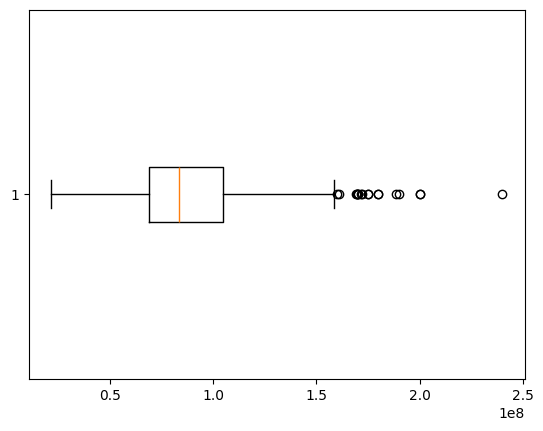

In [69]:
fig = plt.boxplot(copyDf["price"], vert=False)

In [70]:
fig['fliers'][0].get_data() 

(array([1.80000000e+08, 1.71666667e+08, 1.69811321e+08, 1.70000000e+08,
        1.75000000e+08, 1.72000000e+08, 1.69811321e+08, 1.60958904e+08,
        1.70000000e+08, 2.40000000e+08, 1.69230769e+08, 1.60000000e+08,
        1.80000000e+08, 2.00000000e+08, 1.90000000e+08, 1.75000000e+08,
        2.00000000e+08, 1.88679245e+08]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1.]))

In [71]:
Q1 = copyDf["price"].quantile(0.25)
Q3 = copyDf["price"].quantile(0.75)
IQR = Q3-Q1

BM = (copyDf["price"] > (Q3+1.5 *IQR)) | (copyDf["price"] < (Q1-1.5 *IQR))
copyDf[BM]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Elevator,Cooler,User,Fan coil,Basement,Jacuzzi,Secluded yard,Sauna,Yard
2,شهیدعراقی,4,2,1.800000e+08,0,3.0,7,6.0,1,0,...,0,1,1,0,0,0,0,0,0,0
36,شهید عراقی,4,3,1.716667e+08,20,1.0,5,6.0,0,1,...,0,0,1,0,0,0,0,0,0,0
58,تهرانپارس,5,1,1.698113e+08,0,3.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
103,تهرانپارس,5,3,1.700000e+08,1,3.0,7,6.0,1,1,...,1,1,1,0,0,0,1,0,1,1
226,هروی,5,2,1.750000e+08,2,3.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
231,هروی,9,5,1.720000e+08,0,3.0,7,6.0,1,0,...,1,1,1,0,0,0,0,0,0,0
315,تهرانپارس,5,1,1.698113e+08,0,3.0,7,6.0,1,1,...,1,1,1,0,0,0,0,0,0,0
366,شهید عراقی,4,1,1.609589e+08,7,1.0,7,6.0,1,0,...,0,1,1,0,0,0,0,0,0,0
436,تهرانپارس,5,1,1.700000e+08,6,3.0,7,3.0,0,1,...,0,1,0,0,0,0,0,0,0,0
471,شهیدعراقی,5,1,2.400000e+08,0,3.0,8,6.0,1,1,...,0,1,0,0,0,0,0,0,0,0


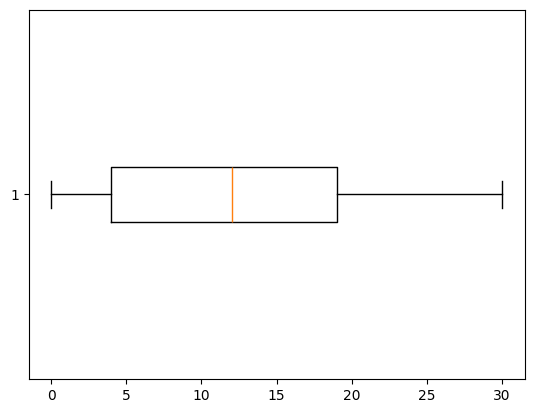

In [72]:
fig = plt.boxplot(copyDf["age"], vert=False)

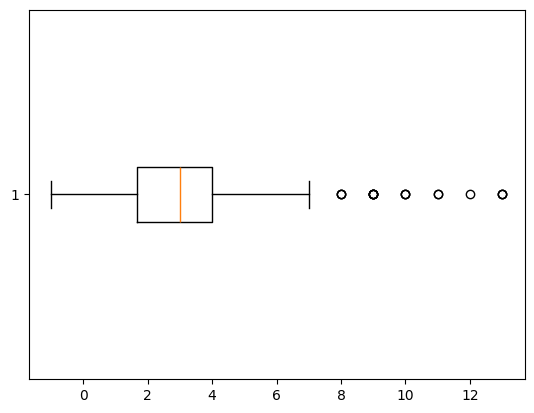

In [73]:
fig = plt.boxplot(copyDf["floor"], vert=False)

In [74]:
fig['fliers'][0].get_data() 

(array([ 9.,  8., 10., 10., 11.,  9.,  9., 13.,  9.,  9., 13., 11.,  8.,
         9., 13., 10.,  8., 12.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1.]))

In [75]:
Q1 = copyDf["floor"].quantile(0.25)
Q3 = copyDf["floor"].quantile(0.75)
IQR = Q3-Q1

BM = (copyDf["floor"] > (Q3+1.5 *IQR)) | (copyDf["floor"] < (Q1-1.5 *IQR))
copyDf[BM]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Elevator,Cooler,User,Fan coil,Basement,Jacuzzi,Secluded yard,Sauna,Yard
77,بزرگراه بابائی شهرك شهپریان,10,8,9.444444e+07,6,1.0,8,4.0,0,1,...,0,1,1,0,0,0,0,0,0,0
181,اتوبان بابایی,19,20,8.350515e+07,1,3.0,-1,4.0,0,1,...,0,1,1,0,0,0,0,0,0,0
197,حكیمیه,12,10,8.817204e+07,5,3.0,7,4.0,0,1,...,0,1,1,0,0,0,0,0,0,0
213,هروی,10,7,1.100000e+08,0,3.0,7,3.0,1,0,...,0,1,1,0,0,0,0,0,0,0
261,هروی,11,9,1.300000e+08,0,3.0,7,6.0,1,0,...,0,1,1,0,0,0,0,0,0,0
273,استخر,9,4,6.560976e+07,20,1.0,7,0.0,1,0,...,0,1,1,0,0,0,0,0,0,0
275,هروی,11,9,1.359223e+08,0,3.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
297,اتوبان بابایی,19,20,8.080808e+07,0,3.0,7,4.0,1,0,...,0,1,1,0,0,0,0,0,0,0
399,جشنواره,9,6,8.500000e+07,2,1.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
472,اتوبان بابایی,10,7,7.010309e+07,10,3.0,7,4.0,1,0,...,1,1,1,0,0,0,0,0,0,0


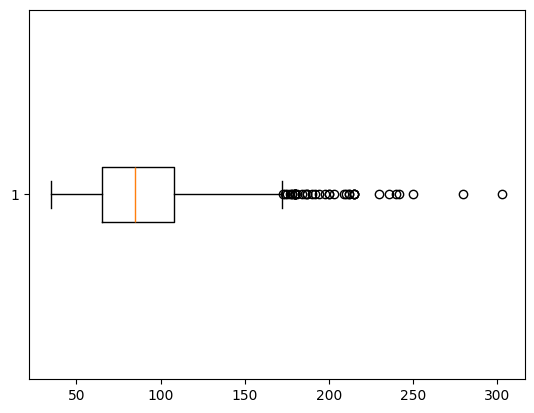

In [76]:
fig = plt.boxplot(copyDf["area"], vert=False)

In [77]:
fig['fliers'][0].get_data() 

(array([209, 187, 173, 212, 215, 178, 215, 187, 181, 200, 212, 178, 210,
        236, 184, 215, 215, 186, 175, 180, 280, 198, 180, 190, 180, 230,
        194, 203, 242, 180, 240, 177, 180, 200, 180, 192, 250, 303, 174,
        180], dtype=int64),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1.]))

In [78]:
Q1 = copyDf["area"].quantile(0.25)
Q3 = copyDf["area"].quantile(0.75)
IQR = Q3-Q1

BM = (copyDf["area"] > (Q3+1.5 *IQR)) | (copyDf["area"] < (Q1-1.5 *IQR))
copyDf[BM]

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Elevator,Cooler,User,Fan coil,Basement,Jacuzzi,Secluded yard,Sauna,Yard
1,تهرانپارس,6,2,1.350000e+08,0,3.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
24,هروی,11,9,1.250000e+08,0,3.0,7,6.0,1,0,...,0,1,1,0,0,0,0,0,0,0
48,تهرانپارس,5,2,1.329480e+08,10,3.0,7,6.0,0,1,...,0,1,1,0,0,0,0,0,0,0
58,تهرانپارس,5,1,1.698113e+08,0,3.0,7,6.0,0,1,...,1,1,1,0,0,0,0,0,0,0
162,تهرانپارس,5,1,1.400000e+08,0,3.0,8,3.0,0,1,...,0,1,0,0,0,0,0,0,0,0
184,هروی,11,9,1.250000e+08,0,3.0,7,6.0,1,0,...,0,1,1,0,0,0,0,0,0,0
209,تهرانپارس,5,1,1.380000e+08,0,3.0,7,6.0,0,1,...,1,1,0,0,0,0,0,0,0,0
210,هروی,11,4,1.203209e+08,0,3.0,8,6.0,0,1,...,0,1,1,0,0,0,0,0,0,0
213,هروی,10,7,1.100000e+08,0,3.0,7,3.0,1,0,...,0,1,1,0,0,0,0,0,0,0
277,تهرانپارس,5,1,1.060000e+08,22,1.0,7,6.0,0,1,...,0,1,1,0,0,0,0,0,0,0


In [789]:
# price_upper_limit = copyDf['price'].mean() + 3 * copyDf['price'].std()
# price_lower_limit = copyDf['price'].mean() - 3 * copyDf['price'].std()


# area_upper_limit = copyDf['area'].mean() + 3 * copyDf['area'].std()
# area_lower_limit = copyDf['area'].mean() - 3 * copyDf['area'].std()

# price_upper_limit, price_lower_limit, area_upper_limit, area_lower_limit
# df = df[(df['price'] <= price_upper_limit) & (df['price'] >= price_lower_limit)]
# df = df[(df['area'] <= area_upper_limit) & (df['area'] >= area_lower_limit)]

In [790]:
# copyDf[(copyDf["area"] > area_lower_limit) & (copyDf["area"] < area_upper_limit)].iloc[:,10:15]

In [791]:
# copyDf[(copyDf["price"] > price_lower_limit) & (copyDf["price"] < price_upper_limit)].iloc[:,2:10]

In [79]:
dummyDf = copyDf.copy()

In [80]:
Q3 = dummyDf.price.quantile(0.75)
Q1 = dummyDf.price.quantile(0.25)
IQR = Q3 - Q1

lower_cap = Q1-IQR*1.5
upper_cap = Q3+IQR*1.5

BM = dummyDf.price < lower_cap
dummyDf.loc[dummyDf[BM].index,'price'] = lower_cap

BM = dummyDf.price > upper_cap
dummyDf.loc[dummyDf[BM].index,'price'] = upper_cap

In [81]:
dummyDf.iloc[:, 1:10]

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought
0,5,2,1.168224e+08,0,3.0,7,6.0,0,1
1,6,2,1.350000e+08,0,3.0,7,6.0,0,1
2,4,2,1.589820e+08,0,3.0,7,6.0,1,0
3,4,1,3.937500e+07,12,1.0,7,0.0,0,1
4,4,2,6.206897e+07,20,3.0,7,6.0,0,1
...,...,...,...,...,...,...,...,...,...
955,4,1,1.030303e+08,17,1.0,7,6.0,1,0
956,5,1,1.400000e+08,0,3.0,7,6.0,0,1
957,5,2,9.793814e+07,10,1.0,7,6.0,1,0
958,4,2,5.428571e+07,12,1.0,7,6.0,0,1


<Axes: >

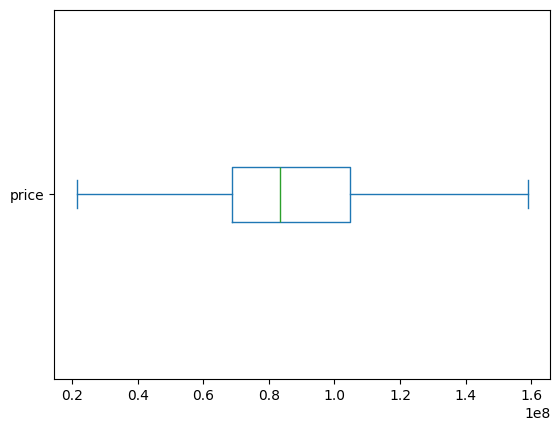

In [82]:
dummyDf["price"].plot.box(vert=False)

In [83]:
Q3 = dummyDf.area.quantile(0.75)
Q1 = dummyDf.area.quantile(0.25)
IQR = Q3 - Q1

lower_cap = Q1-IQR*1.5
upper_cap = Q3+IQR*1.5

BM = dummyDf.area < lower_cap
dummyDf.loc[dummyDf[BM].index,'area'] = lower_cap

BM = dummyDf.area > upper_cap
dummyDf.loc[dummyDf[BM].index,'area'] = upper_cap

C:\Users\Teacher2\AppData\Local\Temp\ipykernel_12452\1830164286.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '172.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummyDf.loc[dummyDf[BM].index,'area'] = upper_cap


In [84]:
dummyDf.iloc[:,1:15]

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,east,floor,area,num_sleep
0,5,2,1.168224e+08,0,3.0,7,6.0,0,1,0,0,2.0,107.0,2
1,6,2,1.350000e+08,0,3.0,7,6.0,0,1,0,0,1.0,172.5,3
2,4,2,1.589820e+08,0,3.0,7,6.0,1,0,0,1,2.0,107.0,2
3,4,1,3.937500e+07,12,1.0,7,0.0,0,1,0,0,0.0,48.0,1
4,4,2,6.206897e+07,20,3.0,7,6.0,0,1,0,0,4.0,58.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,4,1,1.030303e+08,17,1.0,7,6.0,1,0,0,0,1.0,66.0,1
956,5,1,1.400000e+08,0,3.0,7,6.0,0,1,0,0,2.0,172.5,3
957,5,2,9.793814e+07,10,1.0,7,6.0,1,0,0,0,1.0,97.0,2
958,4,2,5.428571e+07,12,1.0,7,6.0,0,1,0,0,4.0,70.0,1


<Axes: >

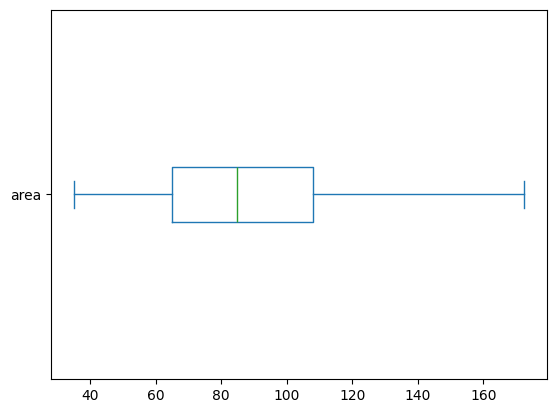

In [85]:
dummyDf["area"].plot.box(vert=False)

In [799]:
# dummyDf = copyDf[(copyDf['price'] <= price_upper_limit) & (copyDf['price'] >= price_lower_limit)]
# dummyDf = copyDf[(copyDf['area'] <= area_upper_limit) & (copyDf['area'] >= area_lower_limit)]

In [800]:
dummyDf

,adress,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,Package,Gas,Pool,Basement,Elevator,items,Cooler,Chiller,Yard,Fan coil
0,تهرانپارس,5,2,1.168224e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
1,تهرانپارس,6,2,1.350000e+08,0,1.0,3,1.0,0,1,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
2,شهیدعراقی,4,2,1.589820e+08,0,1.0,3,1.0,1,0,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
3,جشنواره,4,1,3.937500e+07,12,2.0,3,2.0,0,1,...,0,1,0,0,0,"[کولر, گاز]",1,0,0,0
4,تهرانپارس,4,2,6.206897e+07,20,1.0,3,1.0,0,1,...,0,1,0,0,0,"[شوفاژ, کولر, گاز]",1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,بنی هاشم,4,1,1.030303e+08,17,3.0,3,1.0,1,0,...,0,1,0,0,0,"[شوفاژ, کولر, سونا, جکوزی, گاز]",1,0,0,0
956,تهرانپارس,5,1,1.400000e+08,0,1.0,3,1.0,0,1,...,0,1,0,0,1,"[کولر, آسانسور, گاز]",1,0,0,0
957,تهرانپارس,5,2,9.793814e+07,10,2.0,3,1.0,1,0,...,1,1,0,0,1,"[کولر, آسانسور, پکیج, گاز]",1,0,0,0
958,پروین,4,2,5.428571e+07,12,2.0,3,1.0,0,1,...,1,1,0,0,0,"[کولر, پکیج, گاز]",1,0,0,0


In [801]:
dummyDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   adress          960 non-null    object 
 1   num_floor       960 non-null    int64  
 2   unit_per_floor  960 non-null    int64  
 3   price           960 non-null    float64
 4   age             960 non-null    int32  
 5   statuse         960 non-null    float64
 6   view            960 non-null    int64  
 7   doc_status      959 non-null    float64
 8   north           960 non-null    int64  
 9   sought          960 non-null    int64  
 10  west            960 non-null    int64  
 11  east            960 non-null    int64  
 12  floor           960 non-null    float64
 13  area            960 non-null    float64
 14  num_sleep       960 non-null    int64  
 15  tel             960 non-null    int64  
 16  kitch           959 non-null    float64
 17  service         960 non-null    int

In [86]:
dummyDf.describe()

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,Package,Elevator,Cooler,User,Fan coil,Basement,Jacuzzi,Secluded yard,Sauna,Yard
count,960.000000,960.000000,9.600000e+02,960.000000,960.000000,960.000000,959.000000,960.000000,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,5.005208,2.688542,8.655540e+07,12.095833,1.900000,6.800000,5.325339,0.532292,0.507292,0.023958,...,0.302083,0.632292,0.977083,0.002083,0.003125,0.001042,0.006250,0.007292,0.006250,0.008333
std,2.293613,2.241860,2.886473e+07,8.866945,0.995506,1.369868,1.800746,0.499216,0.500207,0.152999,...,0.459401,0.482433,0.149716,0.045620,0.055843,0.032275,0.078851,0.085124,0.078851,0.090953
min,2.000000,1.000000,2.142857e+07,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,6.875000e+07,4.000000,1.000000,7.000000,6.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,2.000000,8.333333e+07,12.000000,1.000000,7.000000,6.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,3.000000,1.048428e+08,19.000000,3.000000,7.000000,6.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,21.000000,20.000000,1.589820e+08,30.000000,3.000000,10.000000,6.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [89]:
s = dummyDf.isna().sum()
s[s>0]

doc_status    1
dtype: int64

In [92]:
dummyDf[dummyDf['doc_status'].isna()]['doc_status'] = 3

C:\Users\Teacher2\AppData\Local\Temp\ipykernel_12452\1951744591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dummyDf[dummyDf['doc_status'].isna()]['doc_status'] = 3


In [99]:
dummyDf.dtypes[dummyDf.dtypes == 'object']

adress    object
dtype: object

In [100]:
dummyDf.shape

(960, 38)

In [101]:
dummyDf.adress.nunique()

30

In [103]:
dummyDf = pd.get_dummies(dummyDf,prefix='z')
dummyDf.head(10)

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,z_شهیدعراقی,z_فرجام,z_قنات كوثر,z_لویزان,z_مجیدیه,z_میدان شاهد,z_نیروی دریایی,z_هروی,z_هنگام,z_پروین
0,5,2,1.168224e+08,0,3.0,7,6.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
1,6,2,1.350000e+08,0,3.0,7,6.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
2,4,2,1.589820e+08,0,3.0,7,6.0,1,0,0,...,True,False,False,False,False,False,False,False,False,False
3,4,1,3.937500e+07,12,1.0,7,0.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,4,2,6.206897e+07,20,3.0,7,6.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
5,4,4,7.600000e+07,23,1.0,7,6.0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
6,5,4,1.025641e+08,2,3.0,7,6.0,0,1,0,...,False,True,False,False,False,False,False,False,False,False
7,4,2,6.857143e+07,11,3.0,7,6.0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
8,4,1,1.000000e+08,10,1.0,7,6.0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
9,5,2,8.200000e+07,2,3.0,7,6.0,1,0,0,...,False,False,False,False,False,False,False,False,False,False


In [106]:
dummyDf.columns

Index(['num_floor', 'unit_per_floor', 'price', 'age', 'statuse', 'view',
       'doc_status', 'north', 'sought', 'west', 'east', 'floor', 'area',
       'num_sleep', 'tel', 'kitch', 'service', 'floor_covering', 'open',
       'parking', 'warehouse', 'balcony', 'Fireplace', 'Chiller', 'Gas',
       'Patio', 'Pool', 'Package', 'Elevator', 'Cooler', 'User', 'Fan coil',
       'Basement', 'Jacuzzi', 'Secluded yard', 'Sauna', 'Yard',
       'z_اتوبان بابایی', 'z_استخر', 'z_ایت', 'z_بزرگراه بابائی شهرك بهشتی',
       'z_بزرگراه بابائی شهرك شهپریان', 'z_بنی هاشم', 'z_تهرانبارس خ محمدخانی',
       'z_تهرانپارس', 'z_جشنواره', 'z_حكیمیه', 'z_خواجه عبدالله', 'z_دلاوران',
       'z_دماوند', 'z_رسالت', 'z_سراج', 'z_شریعتی', 'z_شمس آّباد',
       'z_شمیران نو', 'z_شهرك راه آهن بلواركوهك', 'z_شهید عراقی',
       'z_شهیدعراقی', 'z_فرجام', 'z_قنات كوثر', 'z_لویزان', 'z_مجیدیه',
       'z_میدان شاهد', 'z_نیروی دریایی', 'z_هروی', 'z_هنگام', 'z_پروین'],
      dtype='object')

In [108]:
pd.get_dummies(df.adress,prefix='z')

,z_اتوبان بابایی,z_استخر,z_ایت,z_بزرگراه بابائی شهرك بهشتی,z_بزرگراه بابائی شهرك شهپریان,z_بنی هاشم,z_تهرانبارس خ محمدخانی,z_تهرانپارس,z_جشنواره,z_حكیمیه,...,z_شهیدعراقی,z_فرجام,z_قنات كوثر,z_لویزان,z_مجیدیه,z_میدان شاهد,z_نیروی دریایی,z_هروی,z_هنگام,z_پروین
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
956,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
957,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
958,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [109]:
df.adress

0      تهرانپارس
1      تهرانپارس
2      شهیدعراقی
3        جشنواره
4      تهرانپارس
         ...    
955     بنی هاشم
956    تهرانپارس
957    تهرانپارس
958        پروین
959        فرجام
Name: adress, Length: 960, dtype: object

In [803]:
dummyDf.to_csv("pr.csv")